# Weighted Fields and Derivative Windows

This notebook shows how the PyHermes field-window language can be used for physical fields carried by a halo catalogue. The same `SFCProjection` machinery that builds an ordinary tracer field can also build velocity-weighted, mass-weighted, and momentum-density fields by changing `field_value`.

With the default `weight_normalization="catalog"`, a field value $x_i$ carried by halo $i$ is represented schematically as

$$
F_x(\mathbf{x}) = \sum_i \frac{w_{g,i}}{\sum_j w_{g,j}} x_i\,\delta_D^{(3)}(\mathbf{x}-\mathbf{x}_i).
$$

For extensive physical fields, such as momentum density, we switch to `weight_normalization="raw"` so that the projected field keeps its raw weighted amplitude.

The notebook is organized around field operations rather than catalogue loops:

1. Build globally smoothed halo count and velocity-weighted fields.
2. Apply derivative windows to measure $\nabla\cdot\mathbf{v}$ and $\nabla\times\mathbf{v}$.
3. Use the inverse-Laplacian and derivative windows to compute the dark-matter potential and acceleration field.
4. Repeat the derivative-window calculation for halo momentum density.
5. Compare derivative windows with a finite-difference reference on a regular grid.

The field calculations are intentionally compact. The longer code blocks are mostly for sampling, slicing, and producing readable figures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyhermes.base.sfc_projection import SFCProjection
from pyhermes.io import read_particle_data
from pyhermes.io.sfc_field import SFCField
from pyhermes.io.window import WindowFunc
from pyhermes.utils.sampling import random_box_positions, regular_grid_positions

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

figs_dir = Path("figs")
figs_dir.mkdir(exist_ok=True)

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


In [2]:
catalog_path = "./data/quijote_halos/8000"
box_size = 1000.0
reader_params = {
    "snapnum": 4,
    "redshift": 0.0,
    "fields": {
        "vx": "vel_x",
        "vy": "vel_y",
        "vz": "vel_z",
        "mass": "mass",
    }
}
halo_data = read_particle_data(catalog_path, data_format="fof", **reader_params)
num_random_points = 300_000
random_pos = random_box_positions(count=num_random_points, box_size=box_size, seed=42).astype(np.float32)


00:50:25 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
00:50:25 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---


In [3]:
base_params = {
    "box_size": box_size,
    "J": 8,
    "wavelet_mode": "db2",
    "wavelet_level": 10,
    "phi_resolution": 1024,
}
threads = 8

smoothing_scale = 10.0  # Mpc/h
win_gauss = WindowFunc(
    {"type": "gaussian", "len_args": {"R": smoothing_scale}},
    base_params,
    threads=threads,
)

print(f"Global Gaussian smoothing scale: R = {smoothing_scale} Mpc/h")

Global Gaussian smoothing scale: R = 10.0 Mpc/h


In [4]:
def build_field(pos, field_value=None, weight_normalization="catalog"):
    task_params = {**base_params, "weight_normalization": weight_normalization}
    task = SFCProjection({"SFCProjection": task_params})
    task.particle_pos = np.array(pos, copy=True)
    if field_value is not None:
        task.field_value = np.array(field_value, copy=True)
    task.threads = threads
    return task.run(save_result=False)

count_data = build_field(halo_data["pos"]) @ win_gauss
v_data = [build_field(halo_data["pos"], field_value=halo_data[key]) @ win_gauss for key in ["vx", "vy", "vz"]]

00:50:27 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
00:50:27 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
0

## 1. Velocity Derivatives From Derivative Windows

A directional derivative is itself a Fourier-space window,

$$
\widetilde{\partial_{\hat n} f}(\mathbf{k}) =
2\pi i(\mathbf{k}\cdot\hat{\mathbf n})\tilde f(\mathbf{k}).
$$

The smoothed halo velocity field is the ratio of velocity-weighted and count fields,

$$
v_i(\mathbf{x}) = \frac{n_{v_i}(\mathbf{x})}{n_h(\mathbf{x})}.
$$

The derivative-window calculation therefore applies the quotient rule,

$$
\partial_j v_i =
\frac{\partial_j n_{v_i}}{n_h}
-
\frac{n_{v_i}\,\partial_j n_h}{n_h^2}.
$$

This is the key PyHermes pattern in this notebook: build the physical fields once, apply derivative windows, and combine the sampled fields algebraically.

In [5]:
from matplotlib.colors import TwoSlopeNorm
deriv_physical_factor = count_data.scale_factor


def make_derivative_window(nx, ny, nz):
    return WindowFunc(
        {
            "type": "directional_derivative",
            "los_args": {"nx": nx, "ny": ny, "nz": nz},
        },
        count_data.sfc_info,
        threads=threads,
    )


derivative_windows = [
    make_derivative_window(1.0, 0.0, 0.0),
    make_derivative_window(0.0, 1.0, 0.0),
    make_derivative_window(0.0, 0.0, 1.0),
]

count_grad_data = [count_data @ window for window in derivative_windows]
v_grad_data = [[component_data @ window for window in derivative_windows] for component_data in v_data]


def sample_fields_at_pos(field_data_list, pos):
    return np.vstack([
        field_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
        for field_data in field_data_list
    ])


def sample_gradient_data(gradient_data, pos, value_unit="physical"):
    gradient = np.empty((len(gradient_data), 3, pos.shape[0]), dtype=np.float64)
    for component_index, component_gradients in enumerate(gradient_data):
        for direction_index, gradient_field in enumerate(component_gradients):
            gradient[component_index, direction_index] = gradient_field.field_density_at_pos(
                pos,
                value_unit=value_unit,
            ).astype(np.float64)
    return gradient * deriv_physical_factor


def sample_directional_derivatives(field_data_list, pos):
    gradient_data = [[field_data @ window for window in derivative_windows] for field_data in field_data_list]
    return sample_gradient_data(gradient_data, pos)


def divergence_and_curl_from_gradient(gradient):
    divergence = gradient[0, 0] + gradient[1, 1] + gradient[2, 2]
    curl = np.column_stack([
        gradient[2, 1] - gradient[1, 2],
        gradient[0, 2] - gradient[2, 0],
        gradient[1, 0] - gradient[0, 1],
    ])
    return divergence, curl


def vector_derivatives_at_pos(component_data_list, pos):
    return divergence_and_curl_from_gradient(sample_directional_derivatives(component_data_list, pos))


def velocity_derivatives_at_pos(pos):
    n_values = count_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
    nv_values = sample_fields_at_pos(v_data, pos)
    dn_values = sample_gradient_data([count_grad_data], pos)[0]
    dnv_values = sample_gradient_data(v_grad_data, pos)
    velocity_gradient = (
        dnv_values / n_values[None, None, :]
        - nv_values[:, None, :] * dn_values[None, :, :] / n_values[None, None, :]**2
    )
    return divergence_and_curl_from_gradient(velocity_gradient)


def symmetric_norm(values, percentile=99.0):
    vmax = np.nanpercentile(np.abs(np.asarray(values, dtype=np.float64)), percentile)
    return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def choose_indices(count, max_count=700, seed=0):
    return np.random.default_rng(seed).choice(count, size=min(max_count, count), replace=False)


def quiver_scale(vectors, fraction=0.055):
    ref = np.nanpercentile(np.linalg.norm(vectors[:, :2], axis=1), 95.0)
    return ref / (fraction * box_size)

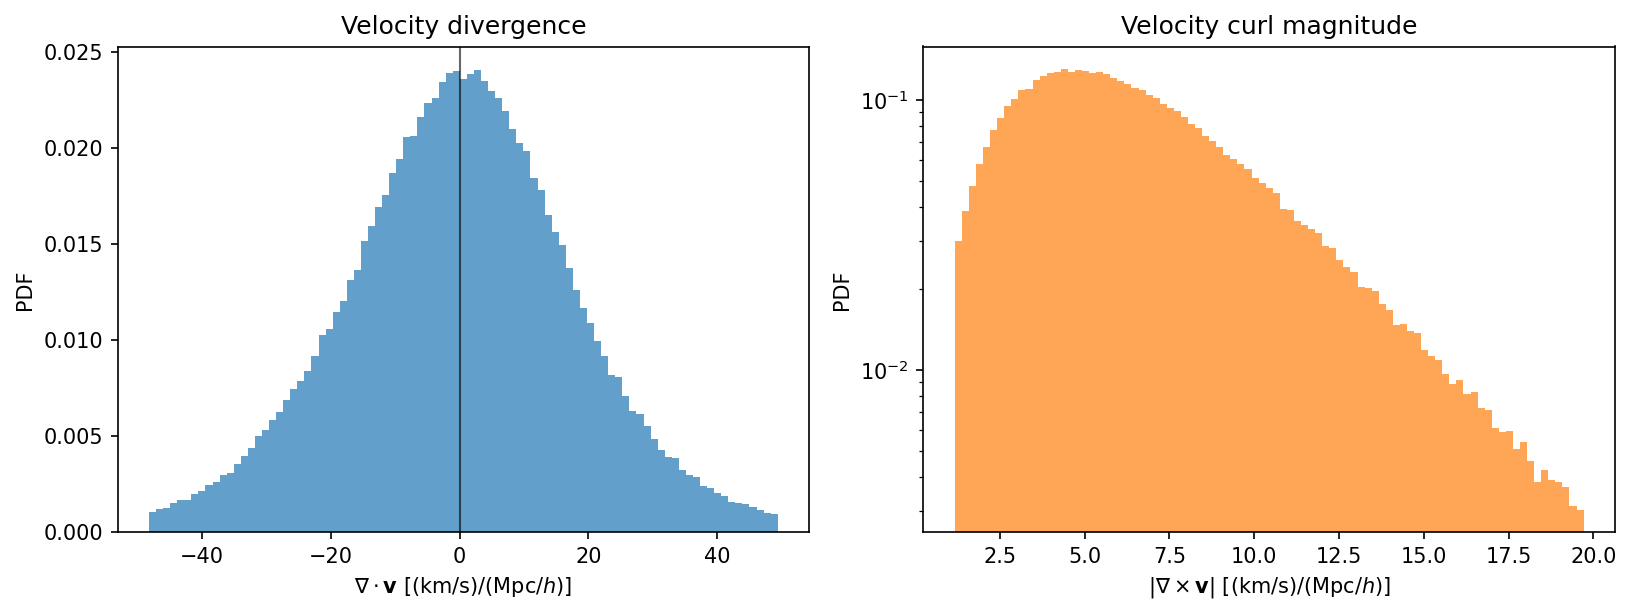

In [6]:
v_div_window_random, v_curl_window_random = velocity_derivatives_at_pos(random_pos)
random_derivative_mask = np.isfinite(v_div_window_random) & np.all(np.isfinite(v_curl_window_random), axis=1)
v_div_window_pdf = v_div_window_random[random_derivative_mask]
v_curl_window_pdf = np.linalg.norm(v_curl_window_random[random_derivative_mask], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_window_pdf, v_curl_window_pdf],
    ["tab:blue", "tab:orange"],
    ["Velocity divergence", "Velocity curl magnitude"],
    [
        r"$\nabla\cdot\mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$|\nabla\times\mathbf{v}|\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True, histtype="stepfilled", color=color, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)
    if "curl" in title.lower():
        ax.set_yscale("log")
    else:
        ax.axvline(0.0, color="k", lw=1, alpha=0.6)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_derivatives_pdf.png", dpi=200, bbox_inches="tight")
plt.show()

### 1.1 Slice and Linear-Theory Comparison

The slice figures use a fixed slab centered at $z=500\ {\rm Mpc}/h$ with thickness $10\ {\rm Mpc}/h$. Background fields are sampled on a regular $x$-$y$ grid. Velocity arrows are sampled at halo positions in the slab and downsampled only for readability.

In [7]:
z0 = 500.0
slice_thickness = 10.0
slice_grid_resolution = 256

halo_dz = (halo_data["pos"][:, 2] - z0 + 0.5 * box_size) % box_size - 0.5 * box_size
halo_slice_mask = np.abs(halo_dz) < 0.5 * slice_thickness
halo_slice_pos = halo_data["pos"][halo_slice_mask].astype(np.float32)
halo_slice_velocity = np.column_stack([
    halo_data["vx"][halo_slice_mask],
    halo_data["vy"][halo_slice_mask],
    halo_data["vz"][halo_slice_mask],
]).astype(np.float64)
halo_velocity_arrow_indices = choose_indices(halo_slice_pos.shape[0], max_count=700, seed=20250629)

slice_axis = ((np.arange(slice_grid_resolution, dtype=np.float32) + 0.5) * box_size / slice_grid_resolution) % box_size
slice_x, slice_y = np.meshgrid(slice_axis, slice_axis, indexing="ij")
slice_eval_pos = np.column_stack([
    slice_x.ravel(),
    slice_y.ravel(),
    np.full(slice_x.size, z0, dtype=np.float32),
]).astype(np.float32)

v_div_slice, _ = velocity_derivatives_at_pos(slice_eval_pos)
v_div_grid = v_div_slice.reshape(slice_x.shape)

dm_sfc_path = Path("output") / "quijote_fiducial_8000_snap004_dm_sfc_J8.pkl"
dm_count_data = SFCField(data_path=str(dm_sfc_path), threads=threads)
dm_density_smoothed = dm_count_data @ win_gauss
dm_delta_data = dm_density_smoothed / dm_density_smoothed.field_mean_density(value_unit="grid") - 1.0
dm_delta_slice = dm_delta_data.field_density_at_pos(slice_eval_pos, value_unit="grid").astype(np.float64)
dm_delta_grid = dm_delta_slice.reshape(slice_x.shape)

omega_m0 = 0.3175
redshift = 0.0
a = 1.0 / (1.0 + redshift)
E_z = np.sqrt(omega_m0 * (1.0 + redshift)**3 + (1.0 - omega_m0))
omega_m_z = omega_m0 * (1.0 + redshift)**3 / E_z**2
f_growth = omega_m_z**0.55
vdiv_to_delta = a * 100.0 * E_z * f_growth  # (km/s)/(Mpc/h)
dm_vdiv_prediction_slice = -dm_delta_slice * vdiv_to_delta
dm_vdiv_prediction_grid = dm_vdiv_prediction_slice.reshape(slice_x.shape)

valid_vdiv_dm = np.isfinite(v_div_slice) & np.isfinite(dm_vdiv_prediction_slice)
vdiv_plot = v_div_slice[valid_vdiv_dm]
prediction_plot = dm_vdiv_prediction_slice[valid_vdiv_dm]
vdiv_plot_limit = np.nanpercentile(np.abs(np.concatenate([vdiv_plot, prediction_plot])), 98.0)

print(f"slice halos = {halo_slice_pos.shape[0]}")
print(f"grid points = {slice_eval_pos.shape[0]}")
print(f"corr(halo velocity divergence, DM linear prediction) = {np.corrcoef(prediction_plot, vdiv_plot)[0, 1]:.4f}")

00:50:52 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> output/quijote_fiducial_8000_snap004_dm_sfc_J8.pkl <---
00:50:52 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -4.192e-06, Max = 3.069e-05, Mean = 5.96e-08, Sum = 1
slice halos = 3824
grid points = 65536
corr(halo velocity divergence, DM linear prediction) = 0.8592


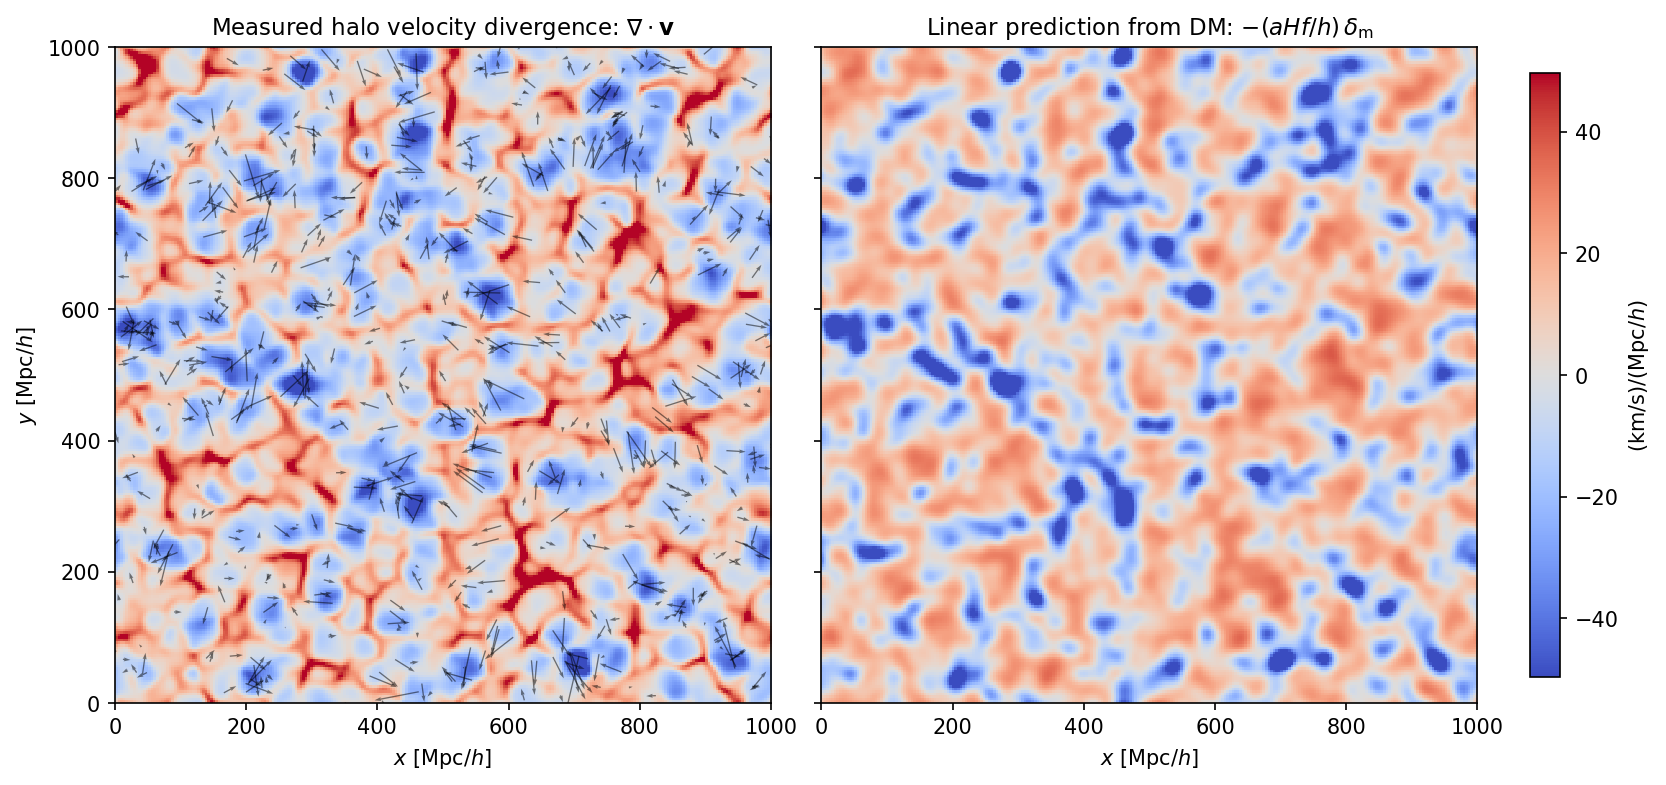

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), dpi=150, constrained_layout=True, sharey=True)

for ax, grid, title in zip(
    axes,
    [v_div_grid, dm_vdiv_prediction_grid],
    [
        r"Measured halo velocity divergence: $\nabla\cdot\mathbf{v}$",
        r"Linear prediction from DM: $-(aHf/h)\,\delta_{\rm m}$",
    ],
):
    im = ax.imshow(
        grid.T,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap="coolwarm",
        vmin=-vdiv_plot_limit,
        vmax=vdiv_plot_limit,
        interpolation="nearest",
    )
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
    ax.set_title(title, fontsize=11)

axes[0].set_ylabel(r"$y\ [{\rm Mpc}/h]$")
axes[0].quiver(
    halo_slice_pos[halo_velocity_arrow_indices, 0],
    halo_slice_pos[halo_velocity_arrow_indices, 1],
    halo_slice_velocity[halo_velocity_arrow_indices, 0],
    halo_slice_velocity[halo_velocity_arrow_indices, 1],
    color="k",
    angles="xy",
    scale_units="xy",
    scale=15,
    width=0.002,
    alpha=0.5,
)

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label(r"$({\rm km}/{\rm s})/({\rm Mpc}/h)$")

fig.savefig(figs_dir / "weighted_fields_velocity_divergence_dm_prediction_slice.png", dpi=200, bbox_inches="tight")
plt.show()


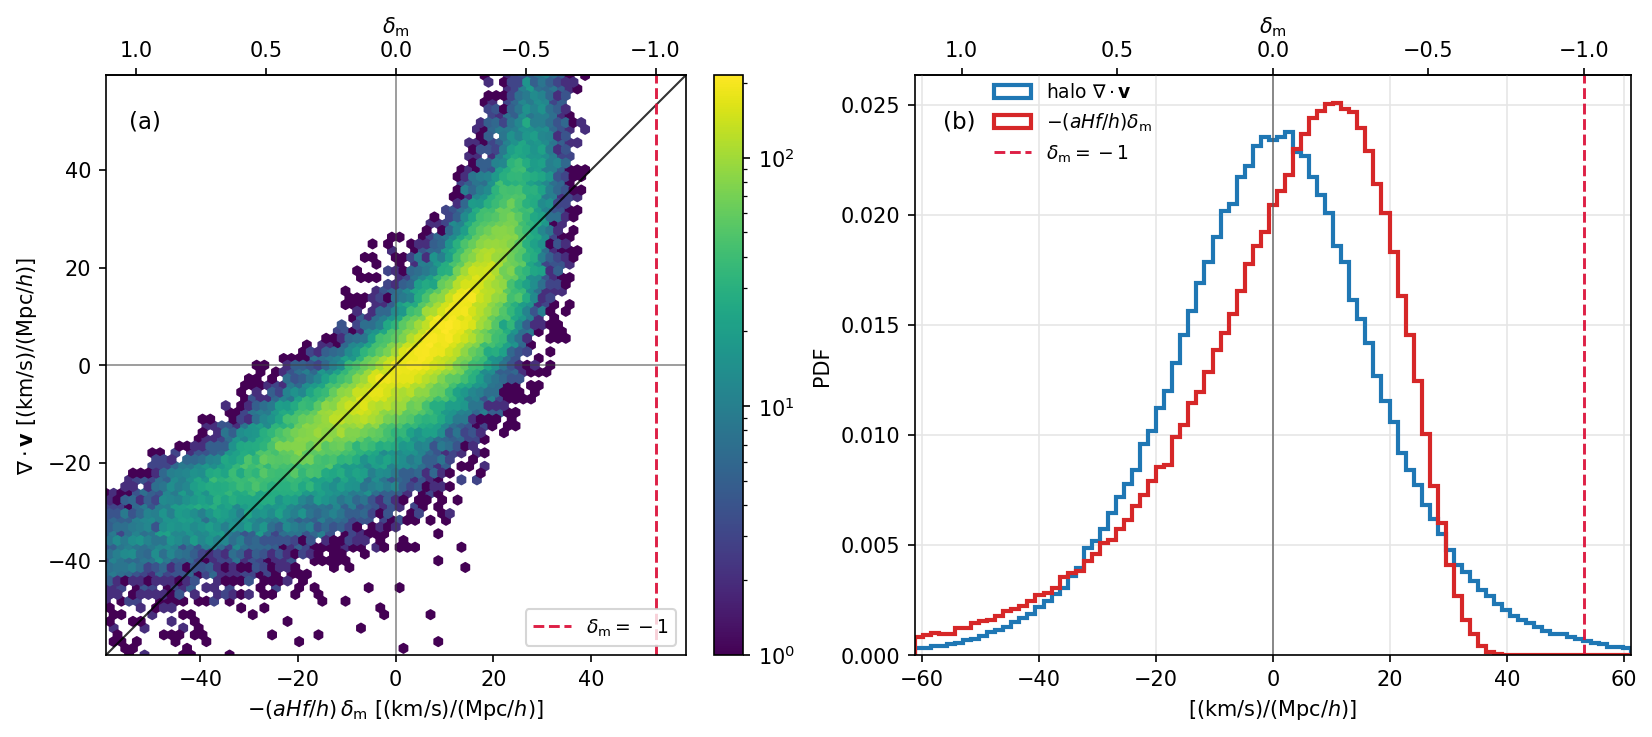

In [9]:
scatter_limit = max(
    np.nanpercentile(np.abs(np.concatenate([prediction_plot, vdiv_plot])), 99.0),
    1.05 * abs(vdiv_to_delta),
)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), dpi=150, constrained_layout=True)

ax = axes[0]
hb = ax.hexbin(
    prediction_plot,
    vdiv_plot,
    gridsize=75,
    bins="log",
    mincnt=1,
    cmap="viridis",
    extent=(-scatter_limit, scatter_limit, -scatter_limit, scatter_limit),
)
ax.plot([-scatter_limit, scatter_limit], [-scatter_limit, scatter_limit], color="k", lw=1, alpha=0.8)
ax.axhline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(vdiv_to_delta, color="crimson", ls="--", lw=1.4, alpha=0.95, label=r"$\delta_{\rm m}=-1$")
ax.set_xlim(-scatter_limit, scatter_limit)
ax.set_ylim(-scatter_limit, scatter_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$-(aHf/h)\,\delta_{\rm m}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.set_ylabel(r"$\nabla\cdot\mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.text(0.04, 0.94, "(a)", transform=ax.transAxes, ha="left", va="top", fontsize=11)
ax.legend(loc="lower right", frameon=True, fontsize=9)
fig.colorbar(hb, ax=ax, fraction=0.047, pad=0.04)

top_ax = ax.secondary_xaxis("top", functions=(lambda x: -x / vdiv_to_delta, lambda delta: -delta * vdiv_to_delta))
top_ax.set_xlabel(r"$\delta_{\rm m}$")
top_ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])

dm_delta_random = dm_delta_data.field_density_at_pos(random_pos, value_unit="grid").astype(np.float64)
prediction_random = -dm_delta_random * vdiv_to_delta
random_pdf_mask = random_derivative_mask & np.isfinite(prediction_random)
vdiv_random_pdf = v_div_window_random[random_pdf_mask]
prediction_random_pdf = prediction_random[random_pdf_mask]
pdf_limit = max(
    np.nanpercentile(np.abs(np.concatenate([vdiv_random_pdf, prediction_random_pdf])), 99.0),
    1.05 * abs(vdiv_to_delta),
)

ax_pdf = axes[1]
bins = np.linspace(-pdf_limit, pdf_limit, 90)
ax_pdf.hist(vdiv_random_pdf, bins=bins, density=True, histtype="step", lw=2.0, color="#1f77b4", label=r"halo $\nabla\cdot\mathbf{v}$")
ax_pdf.hist(prediction_random_pdf, bins=bins, density=True, histtype="step", lw=2.0, color="#d62728", label=r"$-(aHf/h)\delta_{\rm m}$")
ax_pdf.axvline(0.0, color="0.35", lw=0.9, alpha=0.7)
ax_pdf.axvline(vdiv_to_delta, color="crimson", ls="--", lw=1.4, alpha=0.95, label=r"$\delta_{\rm m}=-1$")
ax_pdf.set_xlim(-pdf_limit, pdf_limit)
ax_pdf.set_xlabel(r"$[({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax_pdf.set_ylabel("PDF")
ax_pdf.grid(True, color="0.9", lw=0.8)
ax_pdf.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(0.10, 1.0), borderaxespad=0.0)
ax_pdf.text(0.04, 0.94, "(b)", transform=ax_pdf.transAxes, ha="left", va="top", fontsize=11)

pdf_top_ax = ax_pdf.secondary_xaxis("top", functions=(lambda x: -x / vdiv_to_delta, lambda delta: -delta * vdiv_to_delta))
pdf_top_ax.set_xlabel(r"$\delta_{\rm m}$")
pdf_top_ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])

fig.savefig(figs_dir / "weighted_fields_velocity_divergence_dm_prediction_hexbin.png", dpi=220, bbox_inches="tight")
plt.show()

### 1.2 Dark-Matter Potential From an Inverse-Laplacian Window

Convolving the dark-matter density contrast with the inverse-Laplacian window gives $\nabla^{-2}\delta_m$. Multiplying by the Poisson prefactor then gives the dimensionless mean-zero potential $\Phi/c^2$. This keeps the physical prefactor outside the window definition, so the window remains a clean mathematical operator.

In [10]:
inverse_laplacian_window = WindowFunc({"type": "inverse_laplacian"}, dm_delta_data.sfc_info, threads=threads)
dm_inverse_laplacian_data = dm_delta_data @ inverse_laplacian_window

c_light = 299792.458  # km/s
H0_mpc_over_h = 100.0  # km/s/(Mpc/h)
cell_size = dm_delta_data.box_size / dm_delta_data.L  # Mpc/h
poisson_prefactor = 1.5 * omega_m0 * (H0_mpc_over_h / c_light) ** 2 / a
potential_scale = poisson_prefactor * cell_size**2

dm_potential_data = dm_inverse_laplacian_data * potential_scale
dm_potential_slice = dm_potential_data.field_density_at_pos(slice_eval_pos, value_unit="grid").astype(np.float64)
dm_potential_grid = dm_potential_slice.reshape(slice_x.shape)

print(f"cell_size = {cell_size:.6g} Mpc/h")
print(f"potential scale = {potential_scale:.6e}")


cell_size = 3.90625 Mpc/h
potential scale = 8.085626e-07


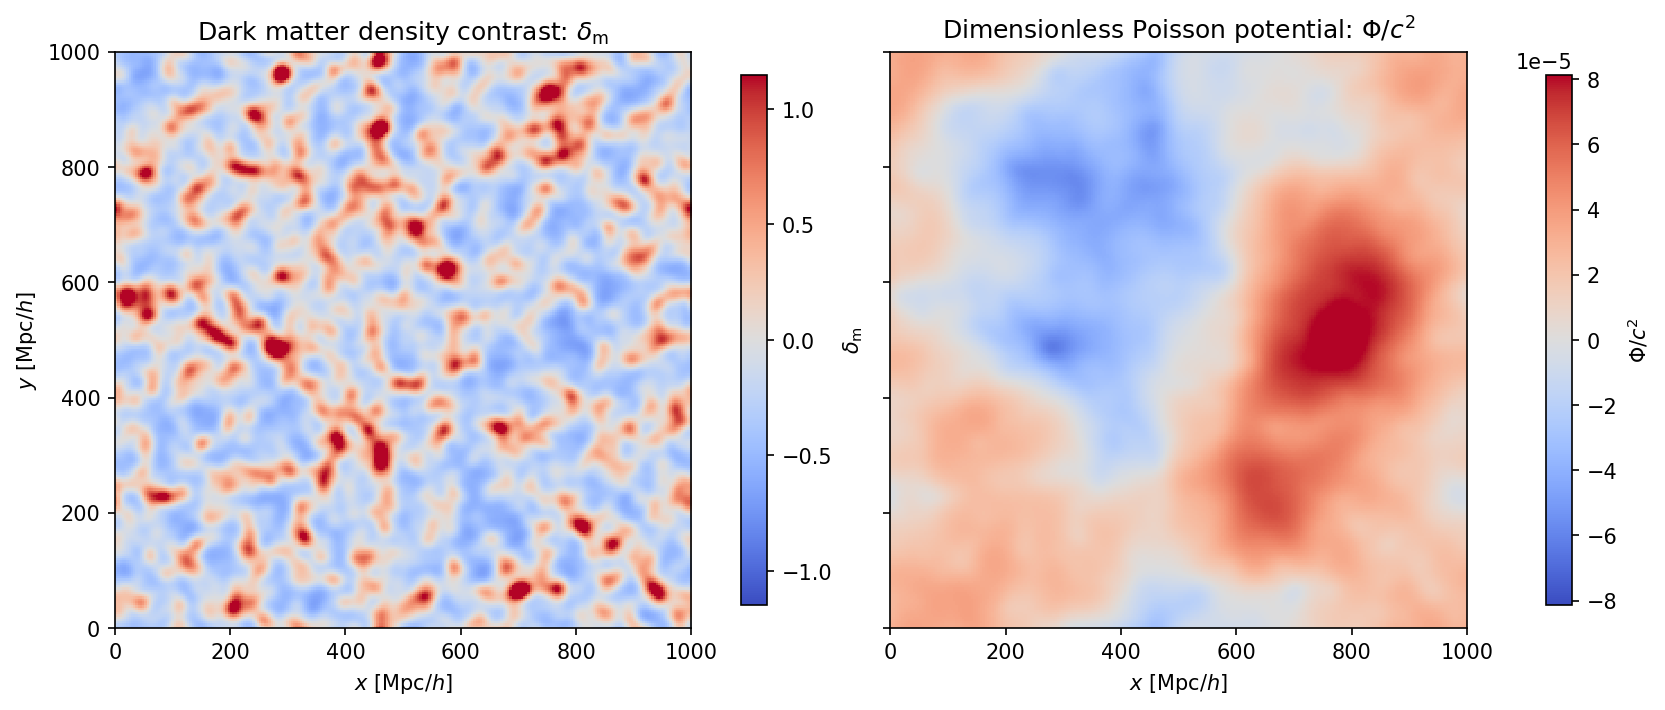

In [11]:
delta_potential_items = [
    (
        dm_delta_grid,
        symmetric_norm(dm_delta_grid, percentile=99.0),
        r"Dark matter density contrast: $\delta_{\rm m}$",
        r"$\delta_{\rm m}$",
    ),
    (
        dm_potential_grid,
        symmetric_norm(dm_potential_grid, percentile=99.0),
        r"Dimensionless Poisson potential: $\Phi/c^2$",
        r"$\Phi/c^2$",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), dpi=150, constrained_layout=True, sharey=True)

for ax, (field_grid, norm, title, cbar_label) in zip(axes, delta_potential_items):
    im = ax.imshow(
        field_grid.T,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap="coolwarm",
        norm=norm,
        interpolation="nearest",
    )
    ax.set_xlim(0.0, box_size)
    ax.set_ylim(0.0, box_size)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
    ax.set_title(title, fontsize=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

axes[0].set_ylabel(r"$y\ [{\rm Mpc}/h]$")
fig.savefig(figs_dir / "weighted_fields_velocity_delta_potential_3panel.png", dpi=220, bbox_inches="tight")
plt.show()


### 1.3 Acceleration From the Potential Gradient

The acceleration field is obtained by differentiating the potential field,

$$
\mathbf{g} = -\frac{c^2}{a}\nabla_x(\Phi/c^2),
$$

and evaluating the result at halo positions in the same slice slab. This is another field-window composition: inverse Laplacian first, derivative windows second.

In [12]:
def sample_scalar_gradient_with_windows(field_data, windows, pos, value_unit="grid"):
    gradient = np.column_stack([
        (field_data @ window).field_density_at_pos(pos, value_unit=value_unit).astype(np.float64)
        for window in windows
    ])
    return gradient * field_data.scale_factor


potential_gradient_at_halos = sample_scalar_gradient_with_windows(dm_potential_data, derivative_windows, halo_slice_pos)
acceleration_prefactor = -(c_light**2) / a
halo_acceleration = acceleration_prefactor * potential_gradient_at_halos

halo_vector_mask = np.all(np.isfinite(halo_slice_velocity), axis=1) & np.all(np.isfinite(halo_acceleration), axis=1)
halo_plot_pos = halo_slice_pos[halo_vector_mask]
halo_velocity_plot = halo_slice_velocity[halo_vector_mask]
halo_acceleration_plot = halo_acceleration[halo_vector_mask]
halo_arrow_indices = choose_indices(halo_plot_pos.shape[0], max_count=700, seed=161803)

print(f"halo-position vector samples = {halo_plot_pos.shape[0]}")
print(f"acceleration prefactor = {acceleration_prefactor:.6e} (km/s)^2")


halo-position vector samples = 3824
acceleration prefactor = -8.987552e+10 (km/s)^2


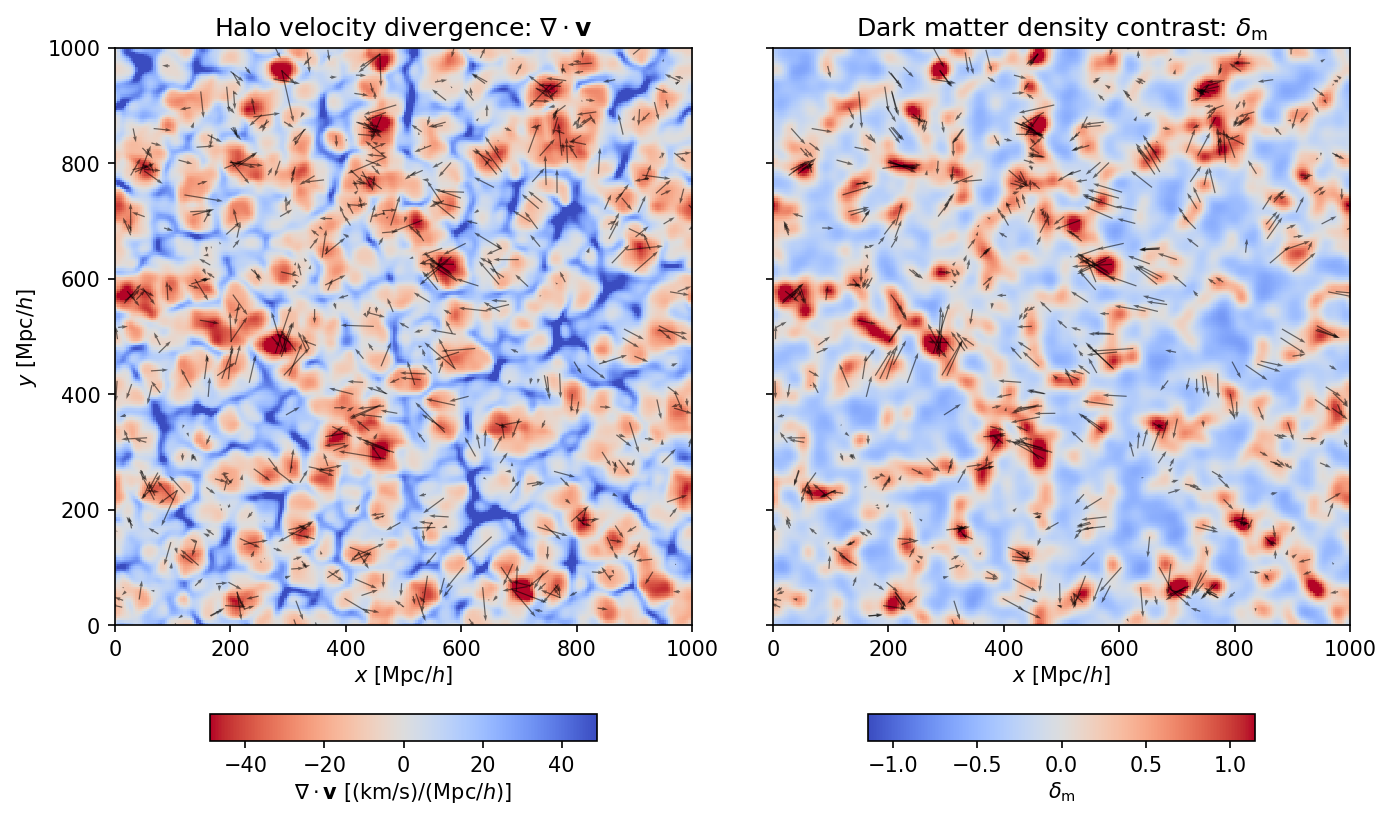

In [13]:
overlay_items = [
    (
        v_div_grid,
        symmetric_norm(v_div_grid, percentile=98.0),
        "coolwarm_r",
        halo_velocity_plot,
        quiver_scale(halo_velocity_plot),
        r"Halo velocity divergence: $\nabla\cdot\mathbf{v}$",
        r"$\nabla\cdot\mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ),
    (
        dm_delta_grid,
        symmetric_norm(dm_delta_grid, percentile=99.0),
        "coolwarm",
        halo_acceleration_plot,
        quiver_scale(halo_acceleration_plot),
        r"Dark matter density contrast: $\delta_{\rm m}$",
        r"$\delta_{\rm m}$",
    ),
]

fig = plt.figure(figsize=(9, 6), dpi=150)
grid = fig.add_gridspec(
    2,
    2,
    height_ratios=(1.0, 0.045),
    left=0.07,
    right=0.985,
    bottom=0.13,
    top=0.91,
    wspace=0.14,
    hspace=0.26,
)

axes = [fig.add_subplot(grid[0, col]) for col in range(2)]
axes[1].tick_params(labelleft=False)

for col, (ax, item) in enumerate(zip(axes, overlay_items)):
    background_grid, norm, cmap, vectors, vector_scale, title, cbar_label = item
    im = ax.imshow(
        background_grid.T,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )
    ax.quiver(
        halo_plot_pos[halo_arrow_indices, 0],
        halo_plot_pos[halo_arrow_indices, 1],
        vectors[halo_arrow_indices, 0],
        vectors[halo_arrow_indices, 1],
        color="k",
        angles="xy",
        scale_units="xy",
        scale=vector_scale,
        width=0.0021,
        alpha=0.55,
        zorder=3,
    )
    ax.set_xlim(0.0, box_size)
    ax.set_ylim(0.0, box_size)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$", labelpad=2)
    ax.set_title(title, fontsize=12)

    cbar_grid = grid[1, col].subgridspec(1, 3, width_ratios=(0.12, 0.76, 0.12))
    cax = fig.add_subplot(cbar_grid[0, 1])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.set_label(cbar_label, labelpad=2)

axes[0].set_ylabel(r"$y\ [{\rm Mpc}/h]$")
fig.savefig(figs_dir / "weighted_fields_velocity_divergence_delta_acceleration_overlay.png", dpi=220, bbox_inches="tight")
plt.show()


## 2. Momentum-Density Derivatives From Derivative Windows

This section adds mass information. The momentum-density components are built with $m_a v_{a,i}$ values,

$$
p_i(\mathbf{x}) = \sum_a m_a v_{a,i} W(\mathbf{x} - \mathbf{x}_a).
$$

Unlike the velocity field, momentum density is a linear weighted field, so no quotient rule is needed. For plotting, derivatives of $\mathbf{p}$ are divided by the mean halo mass density $\bar{\rho}_h$, giving the same velocity-per-length units as the velocity derivatives.

00:51:34 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
00:51:34 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.weight_normalization' from 'catalog' to 'raw'
00:51:34 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 8 threads per rank
00:51:34 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
00:51:34 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
00:51:34 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
00:51:34 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=custom | weight_normalization=raw | catalog_weight_sum=4.0

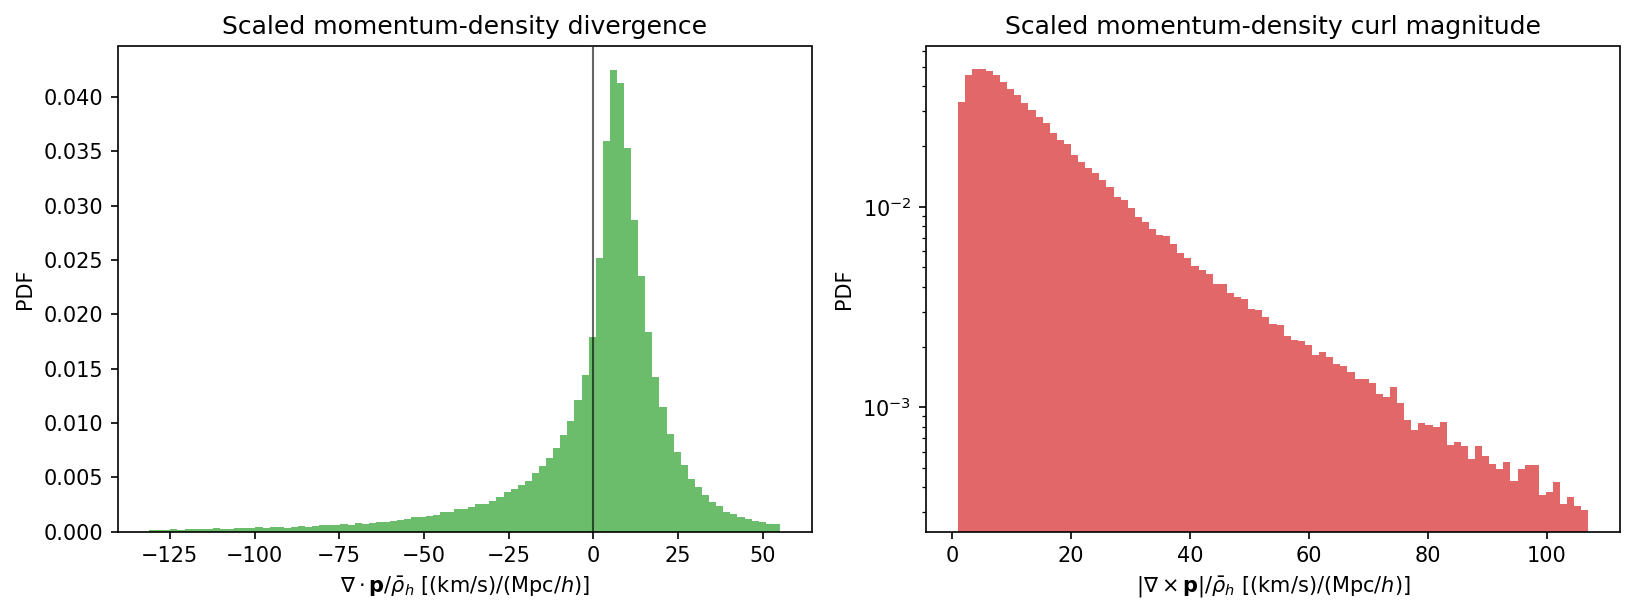

In [14]:
mass_data = build_field(halo_data["pos"], field_value=halo_data["mass"], weight_normalization="raw")
rho_mean = mass_data.field_mean_density(value_unit="physical")
print("mean halo mass density:", rho_mean, "(Msun/h)/(Mpc/h)^3")

p_data = [
    build_field(
        halo_data["pos"],
        field_value=halo_data[velocity_key] * halo_data["mass"],
        weight_normalization="raw",
    ) @ win_gauss
    for velocity_key in ["vx", "vy", "vz"]
]
p_div_window_random, p_curl_window_random = vector_derivatives_at_pos(p_data, random_pos)
p_div_window_pdf = p_div_window_random / rho_mean
p_curl_window_pdf = np.linalg.norm(p_curl_window_random, axis=1) / rho_mean

print("Derivative-window momentum points:", random_pos.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [p_div_window_pdf, p_curl_window_pdf],
    ["tab:green", "tab:red"],
    ["Scaled momentum-density divergence", "Scaled momentum-density curl magnitude"],
    [
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$|\nabla \times \mathbf{p}|/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True, 
            histtype="stepfilled", color=color, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)
    if "curl" in title.lower():
        ax.set_yscale("log")
    else:
        ax.axvline(0.0, color="k", lw=1, alpha=0.6)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_momentum_derivatives_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


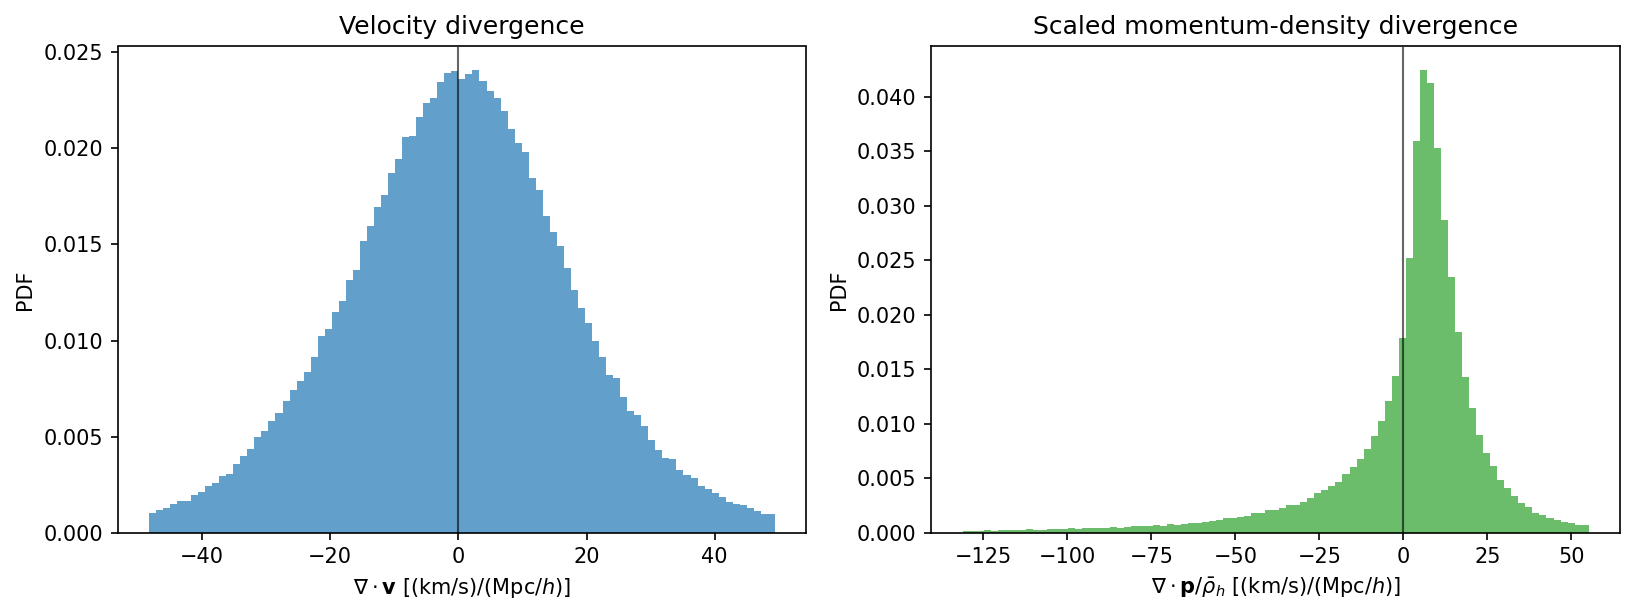

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_window_pdf, p_div_window_pdf],
    ["tab:blue", "tab:green"],
    ["Velocity divergence", "Scaled momentum-density divergence"],
    [
        r"$\nabla \cdot \mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True,
            histtype="stepfilled", color=color, alpha=0.7)
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_momentum_divergence_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Finite-Difference Reference On a Regular Grid

Derivative windows are the native PyHermes route, but finite differences are a useful intuitive reference. The finite-difference calculation below samples the velocity and momentum-density fields on a regular grid and applies a periodic central difference.

The default grid is kept moderate for runtime. Increasing `n_eval_grid` gives a tighter finite-difference reference at higher cost.

In [16]:
def sample_vector_field_grid(component_data_list, pos, n_grid):
    return [
        component_data.field_density_at_pos(pos, value_unit="physical").reshape((n_grid, n_grid, n_grid)).astype(np.float32)
        for component_data in component_data_list
    ]


def sample_velocity_grid(pos, n_grid):
    n_values = count_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
    components = [
        (component_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64) / n_values).reshape((n_grid, n_grid, n_grid)).astype(np.float32)
        for component_data in v_data
    ]
    return components


def periodic_central_diff(field, axis, spacing):
    return (np.roll(field, -1, axis=axis) - np.roll(field, 1, axis=axis)) / (2.0 * spacing)


def vector_field_divergence(x_component, y_component, z_component, spacing):
    return (
        periodic_central_diff(x_component, axis=0, spacing=spacing)
        + periodic_central_diff(y_component, axis=1, spacing=spacing)
        + periodic_central_diff(z_component, axis=2, spacing=spacing)
    )

In [17]:
n_eval_grid = 256
grid_pos, dx = regular_grid_positions(n_eval_grid, box_size)

(vx_grid, vy_grid, vz_grid) = sample_velocity_grid(grid_pos, n_eval_grid)
(px_grid, py_grid, pz_grid) = sample_vector_field_grid(p_data, grid_pos, n_eval_grid)

v_div_fd_grid = vector_field_divergence(vx_grid, vy_grid, vz_grid, spacing=dx)
p_div_fd_grid = vector_field_divergence(px_grid, py_grid, pz_grid, spacing=dx)
velocity_fd_mask = np.isfinite(v_div_fd_grid)

print("finite-difference grid:", f"{n_eval_grid}^3", "dx =", dx, "Mpc/h")
print("finite velocity-divergence cells:", velocity_fd_mask.sum(), "/", v_div_fd_grid.size)
print("momentum divergence cells:", p_div_fd_grid.size)

finite-difference grid: 256^3 dx = 3.90625 Mpc/h
finite velocity-divergence cells: 16777216 / 16777216
momentum divergence cells: 16777216


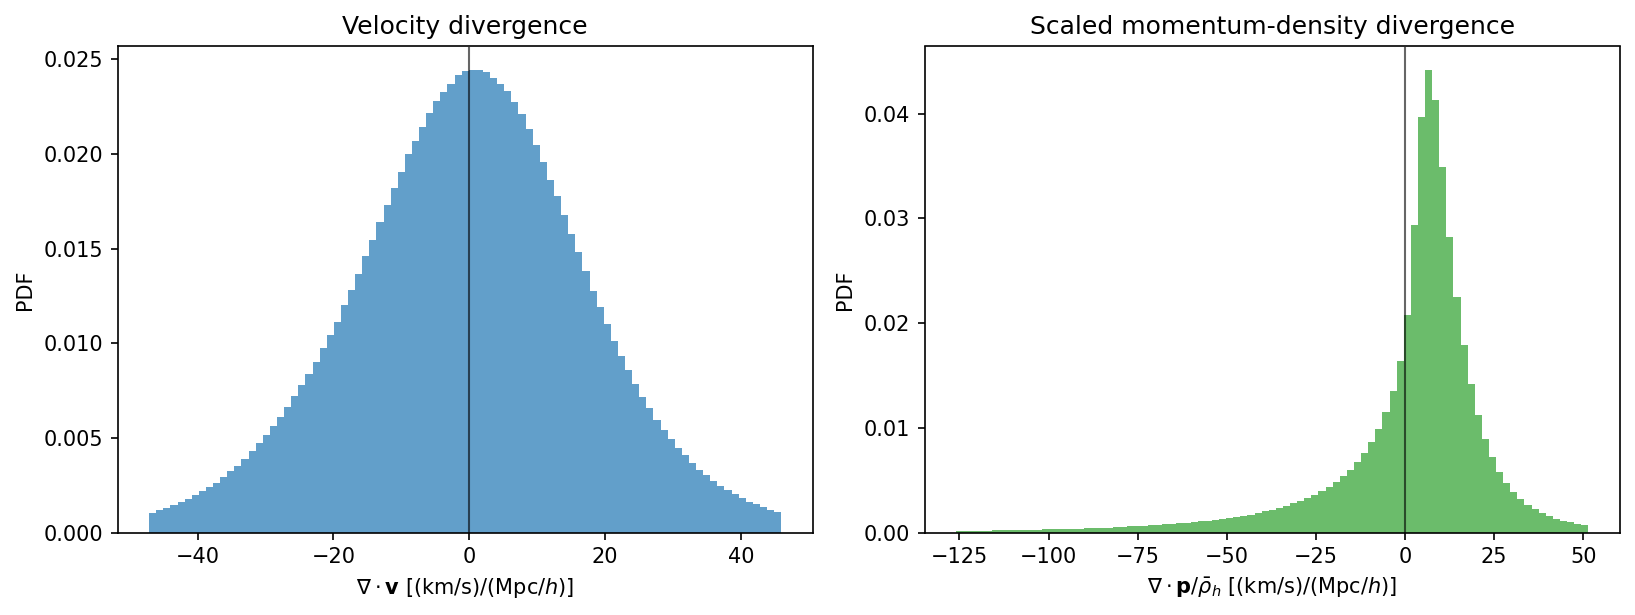

In [18]:
v_div_fd_pdf = v_div_fd_grid[velocity_fd_mask]
p_div_fd_pdf = p_div_fd_grid.ravel() / rho_mean

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_fd_pdf, p_div_fd_pdf],
    ["tab:blue", "tab:green"],
    ["Velocity divergence", "Scaled momentum-density divergence"],
    [
        r"$\nabla \cdot \mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True,
            histtype="stepfilled", color=color, alpha=0.7)
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_finite_difference_divergence_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Derivative Window Versus Finite Difference

Finally, sample a subset of the regular finite-difference grid and evaluate the derivative-window result at the same positions. The comparison uses finite difference on the horizontal axis and derivative windows on the vertical axis.

In [19]:
max_comparison_points = 50_000
comparison_candidates = np.flatnonzero(velocity_fd_mask.ravel())

rng = np.random.default_rng(123)
comparison_index = rng.choice(
    comparison_candidates,
    size=min(max_comparison_points, comparison_candidates.size),
    replace=False,
)
comparison_pos = grid_pos[comparison_index]

v_div_fd_sample = v_div_fd_grid.ravel()[comparison_index]
p_div_fd_sample = p_div_fd_grid.ravel()[comparison_index] / rho_mean

v_div_window_sample, _ = velocity_derivatives_at_pos(comparison_pos)
p_div_window_sample, _ = vector_derivatives_at_pos(p_data, comparison_pos)
p_div_window_sample = p_div_window_sample / rho_mean

v_comparison_mask = np.isfinite(v_div_fd_sample) & np.isfinite(v_div_window_sample)
p_comparison_mask = np.isfinite(p_div_fd_sample) & np.isfinite(p_div_window_sample)
v_div_fd_sample = v_div_fd_sample[v_comparison_mask]
v_div_window_sample = v_div_window_sample[v_comparison_mask]
p_div_fd_sample = p_div_fd_sample[p_comparison_mask]
p_div_window_sample = p_div_window_sample[p_comparison_mask]


def compare_stats(old_values, new_values):
    corr = np.corrcoef(old_values, new_values)[0, 1]
    rms = np.sqrt(np.mean((new_values - old_values) ** 2))
    return corr, rms, old_values.size


v_corr, v_rms, v_n = compare_stats(v_div_fd_sample, v_div_window_sample)
p_corr, p_rms, p_n = compare_stats(p_div_fd_sample, p_div_window_sample)

print(f"Comparison points sampled: {comparison_index.size}")
print(f"Velocity divergence comparison cells: {v_n}, corr={v_corr:.4f}, RMS={v_rms:.4g}")
print(f"Momentum divergence comparison cells: {p_n}, corr={p_corr:.4f}, RMS={p_rms:.4g}")

Comparison points sampled: 50000
Velocity divergence comparison cells: 50000, corr=0.9994, RMS=0.7611
Momentum divergence comparison cells: 50000, corr=0.9998, RMS=0.9133


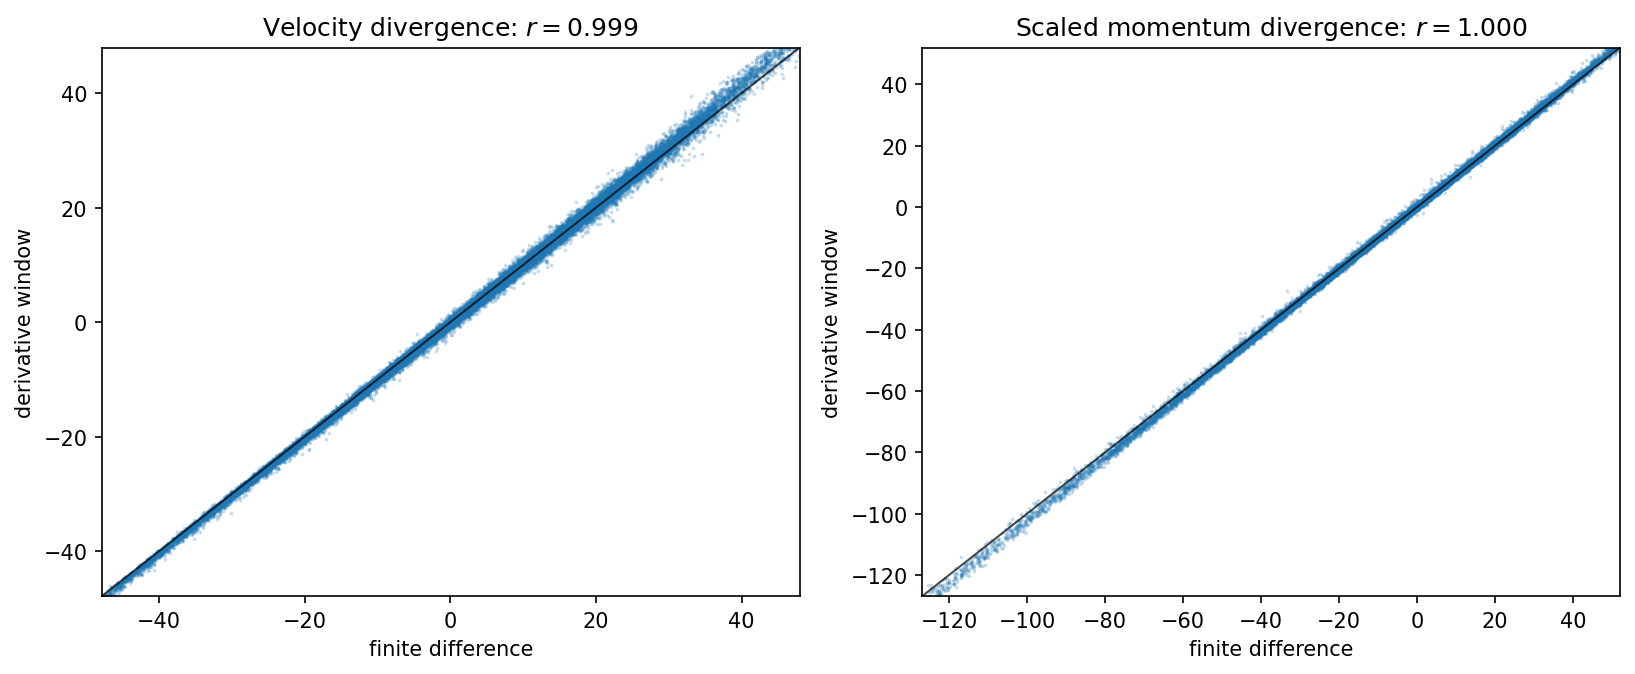

In [20]:
def scatter_compare(ax, old_values, new_values, xlabel, ylabel, title):
    ax.scatter(old_values, new_values, s=3, alpha=0.25, linewidths=0)
    lo, hi = np.percentile(np.concatenate([old_values, new_values]), [1, 99])
    ax.plot([lo, hi], [lo, hi], color="k", lw=1, alpha=0.7)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=150)

scatter_compare(
    axes[0],
    v_div_fd_sample,
    v_div_window_sample,
    "finite difference",
    "derivative window",
    fr"Velocity divergence: $r={v_corr:.3f}$",
)
scatter_compare(
    axes[1],
    p_div_fd_sample,
    p_div_window_sample,
    "finite difference",
    "derivative window",
    fr"Scaled momentum divergence: $r={p_corr:.3f}$",
)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_derivative_window_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
